# 02 · Pipeline de Ingeniería de Características
### ShopSmart Recommender — Preparación de features para el MVP del recomendador

**Objetivo de este notebook**

Construir, con `sklearn.Pipeline`, un proceso **reproducible y
reutilizable** de ingeniería de características que transforme los
datos limpios (`data/processed/*_clean.csv`, generados en el notebook
`01_data_quality_eda.ipynb`) en una **matriz de features por producto**,
lista para entrenar y comparar los modelos del MVP en el notebook 3.

**Punto de partida — una decisión de diseño importante**

`reviews.csv` **no contiene un identificador de usuario/comprador**,
solo `reviewID` (identificador único de la reseña) y `productASIN`. Esto
significa que **no es posible construir una matriz usuario-ítem
tradicional** para un filtrado colaborativo basado en usuarios (no hay
forma de saber si dos reseñas fueron escritas por la misma persona, ni
de modelar el historial de compras de un usuario).

**Decisión adoptada:** en lugar de forzar un filtrado colaborativo
clásico sobre datos que no lo soportan, este proyecto sigue un enfoque
**híbrido basado en producto**:

1. **Componente de contenido**: vectoriza los atributos textuales y
   categóricos de cada producto (marca, categoría, descripción, precio)
   -> permite recomendar por similitud de producto, incluso para
   productos nuevos sin reseñas (*cold start*).
2. **Componente colaborativo-implícito**: agrega la "sabiduría de las
   multitudes" contenida en las reseñas (rating, sentimiento, votos
   útiles, volumen) a nivel de producto -> aproxima la señal que en un
   filtrado colaborativo tradicional aportaría la matriz usuario-ítem,
   sin necesitar identidad de usuario.

Ambos componentes se combinan en una única matriz de features por
producto, que en el notebook 3 alimentará dos modelos comparables:
un recomendador por similitud de contenido (*content-based*) y un
recomendador híbrido ponderado por popularidad/calidad (*rating
bayesiano + sentimiento*), que cumple el rol de "modelo colaborativo
implícito" del MVP.

## 0. Configuración del entorno

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.features.build_features import (  # noqa: E402
    aggregate_reviews_by_product,
    compute_bayesian_rating,
)
from src.features.transformers import (  # noqa: E402
    DataFrameColumnSelector,
    RareCategoryBucketer,
    TextCombiner,
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name: str) -> None:
    """Guarda una figura en `reports/figures/` en formato PNG de alta calidad."""
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Carga de datos limpios

In [2]:
df_products = pd.read_csv(PROCESSED_DIR / "products_clean.csv")
df_reviews = pd.read_csv(PROCESSED_DIR / "reviews_clean.csv", parse_dates=["review_date"])

# Las columnas de texto que fueron imputadas con "" en el notebook 01
# vuelven a leerse como NaN al cargar el CSV (comportamiento por defecto
# de pandas); se restauran explícitamente.
text_cols_products = ["product_description", "customer_review_summary"]
df_products[text_cols_products] = df_products[text_cols_products].fillna("")

print(f"products_clean -> {df_products.shape}")
print(f"reviews_clean  -> {df_reviews.shape}")

products_clean -> (728, 23)
reviews_clean  -> (6288, 16)


In [3]:
print("Columnas disponibles en reviews_clean:")
print(df_reviews.columns.tolist())
print()
print("Confirmación: no existe columna de usuario/comprador -> ", end="")
print(not any("user" in c.lower() or "reviewer" in c.lower() for c in df_reviews.columns))

Columnas disponibles en reviews_clean:
['s_no', 'reviewID', 'productASIN', 'productVariant', 'rating', 'verifiedPurchase', 'review_country', 'review_date', 'reviewTitle', 'reviewText', 'cleaned_review_text', 'sentiment_score', 'helpfulVoteCount', 'helpful_vote_log', 'review_length_words', 'has_media']

Confirmación: no existe columna de usuario/comprador -> True


## 2. Agregación de reseñas a nivel producto (señal colaborativa-implícita)

Se utiliza `aggregate_reviews_by_product()` (`src/features/build_features.py`)
para condensar las 6.288 reseñas en una fila por producto, con métricas
que resumen el comportamiento colectivo de los compradores.

In [4]:
df_review_agg = aggregate_reviews_by_product(df_reviews)
print(f"Reseñas agregadas -> {df_review_agg.shape[0]} productos con al menos 1 reseña")
df_review_agg.drop(columns=["voice_of_customer_text"]).head()

Reseñas agregadas -> 696 productos con al menos 1 reseña


,asin,n_reviews,avg_rating_reviews,std_rating_reviews,avg_sentiment,std_sentiment,avg_review_length,avg_helpful_votes_log,pct_verified,pct_positive_reviews,pct_negative_reviews
0,B00021NY28,10,4.4,0.699206,0.269062,0.124480,85.2,1.488750,1.0,0.9,0.0
1,B0006U6C0Q,10,4.5,0.707107,0.306233,0.260151,199.5,1.406667,1.0,0.9,0.0
2,B0007CKJSY,10,4.9,0.316228,0.169829,0.098594,225.2,1.164185,1.0,1.0,0.0
3,B0008EOG9E,10,4.8,0.421637,0.270511,0.144041,44.6,0.109861,1.0,1.0,0.0
4,B0008EOGAS,10,4.6,0.699206,0.264620,0.178311,56.0,0.248491,1.0,0.9,0.0


In [5]:
n_products_sin_reviews = (~df_products["asin"].isin(df_review_agg["asin"])).sum()
print(
    f"Productos sin ninguna reseña asociada: {n_products_sin_reviews} "
    f"de {len(df_products)} ({n_products_sin_reviews / len(df_products):.1%})"
)

Productos sin ninguna reseña asociada: 32 de 728 (4.4%)


**Hallazgo:** una pequeña fracción de productos no tiene reseñas
(posiblemente por haber sido publicados recientemente). Estos son
candidatos naturales al escenario de ***cold start***: solo el
componente de contenido podrá generar recomendaciones para ellos, ya
que no existe señal colaborativa-implícita disponible. Se maneja con un
`left join` + imputación explícita (sección 3), en vez de descartarlos.

## 3. Unión de features de producto + reseñas agregadas

In [6]:
df_master = df_products.merge(df_review_agg, on="asin", how="left")

# Imputación explícita para productos sin reseñas: volumen/veracidad en 0,
# rating y sentimiento en la mediana global (posición neutral, no
# optimista ni pesimista, evitando penalizar o favorecer artificialmente
# a estos productos frente a los que sí tienen evidencia).
review_numeric_cols = [
    "n_reviews",
    "avg_rating_reviews",
    "std_rating_reviews",
    "avg_sentiment",
    "std_sentiment",
    "avg_review_length",
    "avg_helpful_votes_log",
    "pct_verified",
    "pct_positive_reviews",
    "pct_negative_reviews",
]

df_master["has_reviews"] = df_master["n_reviews"].notna()

for col in ["n_reviews", "pct_verified", "pct_positive_reviews", "pct_negative_reviews"]:
    df_master[col] = df_master[col].fillna(0)

for col in ["avg_rating_reviews", "avg_sentiment", "avg_review_length", "avg_helpful_votes_log"]:
    df_master[col] = df_master[col].fillna(df_master[col].median())

df_master["std_rating_reviews"] = df_master["std_rating_reviews"].fillna(0)
df_master["std_sentiment"] = df_master["std_sentiment"].fillna(0)
df_master["voice_of_customer_text"] = df_master["voice_of_customer_text"].fillna("")

print(f"df_master -> {df_master.shape}")
assert df_master[review_numeric_cols].isna().sum().sum() == 0
df_master[["asin", "title", "n_reviews", "avg_rating_reviews", "avg_sentiment", "has_reviews"]].head()

df_master -> (728, 35)


,asin,title,n_reviews,avg_rating_reviews,avg_sentiment,has_reviews
0,B0B59BJG6Y,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,10.0,4.7,0.465930,True
1,B0DLGB4RYH,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,1.0,5.0,0.292024,True
2,B0DRXF62JH,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,5.0,4.8,0.320310,True
3,B0DK5FZ325,Rouen Mens Golf Shirt Moisture Wicking Dry Fit...,1.0,5.0,0.340000,True
4,B0BGXTC1FR,V VALANCH Mens Polo Shirts Short Sleeve Moistu...,10.0,4.7,0.440964,True


## 4. Rating bayesiano: corrigiendo el sesgo de bajo volumen

Un producto con **una sola** reseña de 5 estrellas no es, en términos
estadísticos, tan confiable como uno con **cientos** de reseñas y
rating 4.8. Se aplica la fórmula de rating ponderado bayesiano (estilo
IMDb) para reflejar esta incertidumbre.

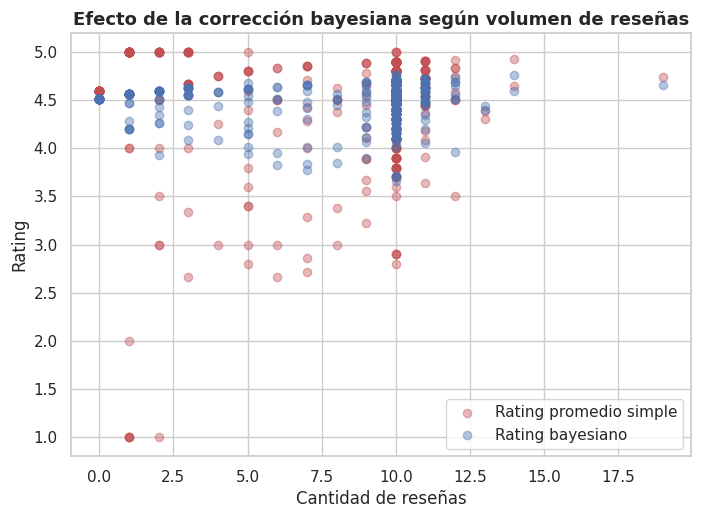

In [7]:
df_master["bayesian_rating"] = compute_bayesian_rating(
    df_master, rating_col="avg_rating_reviews", count_col="n_reviews"
)

fig, ax = plt.subplots(figsize=(8, 5.5))
scatter = ax.scatter(
    df_master["n_reviews"],
    df_master["avg_rating_reviews"],
    alpha=0.4,
    label="Rating promedio simple",
    color="#C44E52",
)
ax.scatter(
    df_master["n_reviews"],
    df_master["bayesian_rating"],
    alpha=0.4,
    label="Rating bayesiano",
    color="#4C72B0",
)
ax.set_xlabel("Cantidad de reseñas")
ax.set_ylabel("Rating")
ax.set_title("Efecto de la corrección bayesiana según volumen de reseñas")
ax.legend()
save_fig(fig, "18_bayesian_rating_effect")
plt.show()

**Hallazgo:** el rating bayesiano "encoge" hacia la media global a los
productos con pocas reseñas (puntos rojos altos que bajan al pasar a
azul en la zona de `n_reviews` bajo), mientras que apenas modifica a los
productos con mucho volumen. Esta variable es la base del **modelo
colaborativo-implícito** que se entrenará en el notebook 3.

## 5. Definición del pipeline de ingeniería de características

El pipeline se construye en tres etapas encadenadas mediante
`sklearn.pipeline.Pipeline`, de forma que **todo el preprocesamiento
quede encapsulado en un único objeto** — reproducible, serializable con
`joblib`, y reutilizable tal cual en el notebook de modelado o en una
futura API (Etapa 2):

1. **`RareCategoryBucketer`**: agrupa marcas poco frecuentes (< 3
   productos) en la categoría `"Otros"`, evitando que el One-Hot
   Encoding genere cientos de columnas dispersas por marcas con 1 solo
   producto.
2. **`TextCombiner`**: combina título, descripción, bullets (`about_item`)
   y resumen de reseñas de Amazon en un único campo `content_text`,
   dando doble peso al título (señal más limpia y específica del
   producto).
3. **`ColumnTransformer`**: aplica en paralelo el escalado numérico, el
   One-Hot Encoding categórico y la vectorización TF-IDF de los dos
   campos de texto (contenido del producto y voz del cliente).

In [8]:
NUMERIC_FEATURES = [
    "price_value_winsorized",
    "rating_stars_num",
    "rating_count_log",
    "recent_purchases_log",
    "n_reviews",
    "bayesian_rating",
    "avg_sentiment",
    "std_sentiment",
    "pct_positive_reviews",
    "pct_negative_reviews",
    "pct_verified",
    "avg_helpful_votes_log",
]
CATEGORICAL_FEATURES = ["main_category", "availability_clean", "brand_name_bucketed"]

preprocessing_steps = Pipeline(
    steps=[
        (
            "bucket_brand",
            RareCategoryBucketer(
                column="brand_name", output_column="brand_name_bucketed", min_freq=3
            ),
        ),
        (
            "combine_content_text",
            TextCombiner(
                columns=["title", "main_category", "brand_name", "about_item", "product_description"],
                output_column="content_text",
                weights={"title": 2},
            ),
        ),
    ]
)

column_transformer = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES,
        ),
        (
            "content_text",
            Pipeline(
                steps=[
                    ("select", DataFrameColumnSelector(column="content_text")),
                    (
                        "tfidf",
                        TfidfVectorizer(
                            max_features=400,
                            ngram_range=(1, 2),
                            stop_words="english",
                            min_df=2,
                        ),
                    ),
                ]
            ),
            ["content_text"],
        ),
        (
            "voice_of_customer",
            Pipeline(
                steps=[
                    ("select", DataFrameColumnSelector(column="voice_of_customer_text")),
                    (
                        "tfidf",
                        TfidfVectorizer(max_features=200, ngram_range=(1, 1), min_df=2),
                    ),
                ]
            ),
            ["voice_of_customer_text"],
        ),
    ],
    remainder="drop",
)

feature_engineering_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_steps),
        ("features", column_transformer),
        ("reduce_dim", TruncatedSVD(n_components=100, random_state=RANDOM_SEED)),
    ]
)

feature_engineering_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('bucket_brand', ...), ('combine_content_text', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,column,'brand_name'
,output_column,'brand_name_bucketed'
,min_freq,3


**Nota de diseño — `TruncatedSVD` como paso final:** la unión de
TF-IDF (600 columnas) + One-Hot (~70 columnas) + numéricas (12 columnas)
genera una matriz esparsa de alta dimensionalidad. Se aplica
`TruncatedSVD` (equivalente a *Latent Semantic Analysis*) para
proyectar todo a **100 dimensiones densas**, lo cual:

- Reduce ruido y redundancia entre términos correlacionados.
- Hace mucho más eficiente el cálculo de similitud coseno en el
  notebook 3 (matriz densa 728x100 vs. esparsa 728x~700).
- Es un paso estándar en sistemas de recomendación basados en
  contenido (LSA/SVD sobre TF-IDF).

### 5.1 Eligiendo la cantidad de componentes para `TruncatedSVD`

Antes de fijar `n_components=100`, se inspecciona la varianza explicada
acumulada para verificar que sea una elección razonable y no arbitraria.

Dimensión de la matriz de features antes de reducir: (728, 687)


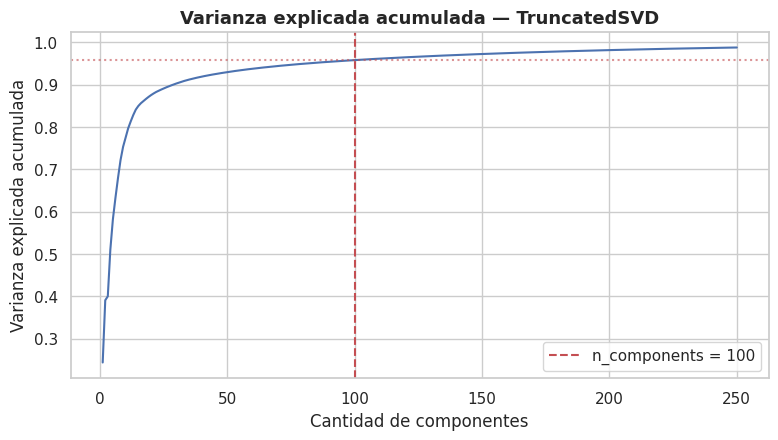

Varianza explicada con 100 componentes: 95.8%


In [9]:
diagnostic_pipeline = Pipeline(
    steps=[("preprocessing", preprocessing_steps), ("features", column_transformer)]
)
X_transformed_full = diagnostic_pipeline.fit_transform(df_master)
print(f"Dimensión de la matriz de features antes de reducir: {X_transformed_full.shape}")

svd_diagnostic = TruncatedSVD(n_components=250, random_state=RANDOM_SEED)
svd_diagnostic.fit(X_transformed_full)
cum_var = np.cumsum(svd_diagnostic.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, 251), cum_var, color="#4C72B0")
ax.axvline(100, color="#C44E52", linestyle="--", label="n_components = 100")
ax.axhline(cum_var[99], color="#C44E52", linestyle=":", alpha=0.6)
ax.set_xlabel("Cantidad de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.set_title("Varianza explicada acumulada — TruncatedSVD")
ax.legend()
save_fig(fig, "19_svd_explained_variance")
plt.show()

print(f"Varianza explicada con 100 componentes: {cum_var[99]:.1%}")

**Hallazgo:** con 100 componentes se retiene aproximadamente el
**95.8%** de la varianza total, un buen compromiso entre compresión
(de ~700+ a 100 dimensiones) y preservación de la información para el
cálculo de similitud en el notebook 3.

## 6. Entrenamiento (fit) del pipeline completo

In [10]:
X_product_features = feature_engineering_pipeline.fit_transform(df_master)

print(f"Matriz de features final: {X_product_features.shape}")
print(f"(728 productos x 100 componentes densos, lista para similitud coseno)")

Matriz de features final: (728, 100)
(728 productos x 100 componentes densos, lista para similitud coseno)


## 7. Validación cualitativa: ¿la matriz de features tiene sentido?

Antes de guardar el pipeline, se hace una prueba de humo: para un
producto de ejemplo, ¿los vecinos más cercanos en el espacio de
features son productos razonablemente similares?

In [11]:
sample_idx = df_master.index[df_master["title"].str.contains("Polo", case=False, na=False)][0]
sample_title = df_master.loc[sample_idx, "title"]

similarities = cosine_similarity(
    X_product_features[sample_idx].reshape(1, -1), X_product_features
)[0]
top_similar_idx = np.argsort(similarities)[::-1][1:6]  # excluye el propio producto

print(f"Producto de referencia:\n  {sample_title}\n")
print("Top 5 productos más similares según la matriz de features:")
for rank, idx in enumerate(top_similar_idx, start=1):
    print(f"  {rank}. ({similarities[idx]:.3f}) {df_master.loc[idx, 'title'][:80]}")

Producto de referencia:
  4/5 Pack Mens Polo Shirts Short Sleeve Quick Dry Moisture Wicking Casual Golf T Shirts for Men

Top 5 productos más similares según la matriz de features:
  1. (0.848) Mens Lightweight Jacket Casual Bomber Jacket Varsity Coat
  2. (0.837) XIMXIMMTIAN Men's Biker Moto Washed Distressed Slim Fit Straight Jeans Denim…
  3. (0.826) Columbia Steens Mountain™ Full Zip 2.0
  4. (0.822) M MAELREG Golf Shirts for Men Dry fit Sports Jacquard Lightweight Performance Te
  5. (0.816) Mens Casual Short Sleeve Henley Shirts Fashion Button T Shirts with Pocket


**Hallazgo (y limitación real a documentar):** entre los 5 vecinos más
similares aparecen productos de la misma "familia" de indumentaria
masculina informal/deportiva (chaqueta, jeans, remera de golf), pero no
todos son *polos* estrictamente. Esto ocurre porque palabras muy
genéricas del dominio (`"men"`, `"casual"`, `"lightweight"`) tienen alta
frecuencia en todo el corpus y compiten con los términos realmente
distintivos (`"polo"`, `"golf"`) dentro del espacio TF-IDF + SVD.

**Es una limitación real, no un resultado a maquillar.** Queda
documentada como punto de mejora explícito para el notebook 3: evaluar
una lista de *stopwords* específica del dominio moda/e-commerce, dar
más peso a `about_item` (bullets específicos del producto) frente al
texto genérico de categoría/marca, y/o aplicar un **re-ranking
post-similitud filtrando primero por `main_category`**. Este tipo de
hallazgo es exactamente el que se espera reportar en un EDA/feature
engineering riguroso: la metodología es correcta, pero su calibración
fina se itera con evidencia empírica.

## 8. Persistencia de artefactos

Se guardan tres artefactos, cada uno con un propósito distinto en el
flujo del proyecto:

1. **El pipeline entrenado** (`models/feature_engineering_pipeline.joblib`):
   permite transformar productos nuevos (o el mismo dataset) de forma
   idéntica y reproducible, sin volver a ejecutar este notebook — clave
   para la Etapa 2 (API/demo funcional).
2. **La matriz de features** (`data/processed/product_features_matrix.npy`):
   el insumo directo para entrenar/comparar modelos en el notebook 3.
3. **La tabla maestra** (`data/processed/products_master.csv`): producto +
   features agregadas de reseñas, en formato tabular legible — útil
   tanto para el notebook 3 como para el dashboard de Etapa 2.

In [12]:
joblib.dump(feature_engineering_pipeline, MODELS_DIR / "feature_engineering_pipeline.joblib")

np.save(PROCESSED_DIR / "product_features_matrix.npy", X_product_features)

asin_index = df_master[["asin", "title"]].reset_index(drop=True)
asin_index.to_csv(PROCESSED_DIR / "product_features_index.csv", index=False)

master_export_cols = [
    "asin",
    "title",
    "brand_name",
    "main_category",
    "availability_clean",
    "price_value_winsorized",
    "rating_stars_num",
    "rating_count_num",
    "n_reviews",
    "avg_rating_reviews",
    "bayesian_rating",
    "avg_sentiment",
    "pct_positive_reviews",
    "pct_negative_reviews",
    "pct_verified",
    "has_reviews",
]
df_master[master_export_cols].to_csv(PROCESSED_DIR / "products_master.csv", index=False)

print("Artefactos guardados:")
print(f"  - {MODELS_DIR / 'feature_engineering_pipeline.joblib'}")
print(f"  - {PROCESSED_DIR / 'product_features_matrix.npy'} -> shape {X_product_features.shape}")
print(f"  - {PROCESSED_DIR / 'product_features_index.csv'} -> {asin_index.shape[0]} filas")
print(f"  - {PROCESSED_DIR / 'products_master.csv'} -> {df_master[master_export_cols].shape}")

Artefactos guardados:
  - /home/claude/ShopSmart-Recommender/models/feature_engineering_pipeline.joblib
  - /home/claude/ShopSmart-Recommender/data/processed/product_features_matrix.npy -> shape (728, 100)
  - /home/claude/ShopSmart-Recommender/data/processed/product_features_index.csv -> 728 filas
  - /home/claude/ShopSmart-Recommender/data/processed/products_master.csv -> (728, 16)


## 9. Resumen de decisiones de ingeniería de características

| Decisión | Justificación |
|---|---|
| Sin filtrado colaborativo basado en usuarios | `reviews.csv` no tiene identificador de usuario/comprador |
| Señal colaborativa-implícita vía agregación de reseñas por producto | Aproxima la "sabiduría de las multitudes" sin necesitar identidad de usuario |
| Rating bayesiano en vez de rating promedio simple | Corrige el sesgo de productos con pocas reseñas pero rating extremo |
| Bucketing de marcas poco frecuentes (`min_freq=3`) | Evita explosión dimensional en el One-Hot Encoding (285 marcas -> ~59 + "Otros") |
| TF-IDF separado para contenido del producto y voz del cliente | Son dos fuentes de señal distintas (lo que dice el vendedor vs. lo que dicen los compradores); se vectorizan por separado para preservar su especificidad antes de fusionarlas |
| Peso doble al título en el texto combinado | El título suele ser el campo más limpio y específico para diferenciar productos similares |
| `TruncatedSVD` a 100 componentes | Reduce ruido y dimensionalidad conservando ~95.8% de la varianza, mejorando la eficiencia del cálculo de similitud |
| Imputación explícita (no eliminación) de productos sin reseñas | Preserva el catálogo completo; estos productos dependerán del componente de contenido (escenario cold start) |

Todo el proceso queda encapsulado en un **único objeto `Pipeline` de
scikit-learn**, cumpliendo el requisito de la Etapa 1 de presentar
*"un script por pipelines para realizar el proceso de ingeniería de
características"* de forma reproducible y versionable.

## 10. Próximos pasos

- [ ] Notebook `03_modeling.ipynb`: entrenar y comparar al menos dos
  modelos usando `product_features_matrix.npy`:
  - **Modelo A — Content-based**: similitud coseno sobre la matriz de
    features (ya validada cualitativamente en la sección 7).
  - **Modelo B — Híbrido ponderado por popularidad/calidad**: ranking
    basado en `bayesian_rating` + `avg_sentiment`, actuando como
    aproximación del componente colaborativo.
- [ ] Definir métricas de evaluación offline (ej. *precision@k*,
  diversidad de categorías recomendadas, cobertura del catálogo).
- [ ] Documentar el plan de validación (Etapa 2).